# HITO 2 – Análisis de Datos y Formulación del Problema
## Proyecto Guardian AI


## Índice del notebook

1. Importación de librerías
2. Carga del Dataset
3. Inspección estructural
4. Distribuciones
   - 4.1. Distribuciones de variables continuas
   - 4.2. Distribuciones de variables discretas
   - 4.3. Distribuciones de variables categóricas
5. Correlaciones
6. Análisis por categoría
7. Búsqueda de perfiles con otras variables
   - 7.1. Resumen de Hallazgos del Análisis de Variables
8. Búsqueda de perfiles en las variables categóricas
9. Conclusiones Finales y Resumen Ejecutivo

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
import itertools
import seaborn as sns


Se ha escogido el dataset siguiente:

    https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022?select=Base.csv
    
Entre los motivos, que son datos sintéticos creados en 2022, entre los motivos están la cantidad de variables que incorpora, que reune datos de 6 datasets distintos, que incorpora un millón de transacciones y que se han generado teniendo en cuenta patrones reales de fraudes bancarios, además, entre los datos se incluyen variables que determinan si una transacción es fraudulenta o no, lo que permite utilizar modelos de aprendizaje supervisado, además, al ser sintético nos permite no tener que preocuparnos por fugas de datos o la privacidad de los mismos.

## Carga del Dataset

In [2]:
pd.set_option('display.max_columns',None)
df = pd.read_csv("Base.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


Podemos observar que, el dataset está compuesto de 1 millón de transacciones y unas 32 variables por transacción.

A eventos de clarificar el significado de cada variable, hemos acudido a su descripción https://github.com/feedzai/bank-account-fraud/blob/main/documents/datasheet.pdf y nos ha permitido obtener las descripciones siguientes:

- income (numérico): Ingresos anuales del solicitante (en forma de decil). El rango es de [0.1, 0.9].
- name_email_similarity (numérico): Métrica de similitud entre el correo electrónico y el nombre del solicitante. Los valores más altos representan una mayor similitud. El rango es de [0, 1].
- prev_address_months_count (numérico): Número de meses en la dirección registrada anterior del solicitante, es decir, su residencia anterior, si corresponde. El rango es de [−1, 380] meses (-1 es un valor faltante).
- current_address_months_count (numérico): Meses en la dirección registrada actual del solicitante. El rango es de [−1, 429] meses (-1 es un valor faltante).
- customer_age (numérico): Edad del solicitante en años, redondeada a la década. El rango es de [10, 90] años.
- days_since_request (numérico): Número de días transcurridos desde la solicitud. El rango varía entre [0, 79] días.
- intended_balcon_amount (numérico): Importe inicial transferido para la solicitud. El rango varía entre [−16, 114] (los valores negativos son valores faltantes).
- payment_type (categórico): Tipo de plan de pago a crédito. 5 valores posibles (anonimizados).
- zip_count_4w (numérico): Número de solicitudes dentro del mismo código postal en las últimas 4 semanas. El rango varía entre [1, 6830].
- velocity_6h (numérico): Velocidad total de solicitudes realizadas en las últimas 6 horas, es decir, promedio de solicitudes por hora en las últimas 6 horas. El rango varía entre [−175, 16818].
- velocity_24h (numérico): Velocidad total de solicitudes realizadas en las últimas 24 horas, es decir, el promedio de solicitudes por hora en las últimas 24 horas. El rango es [1297, 9586].
- velocity_4w (numérico): Velocidad total de solicitudes realizadas en las últimas 4 semanas, es decir, el promedio de solicitudes por hora en las últimas 4 semanas. El rango es [2825, 7020].
- bank_branch_count_8w (numérico): Número total de solicitudes en la sucursal bancaria seleccionada en las últimas 8 semanas. El rango es [0, 2404].
- date_of_birth_distinct_emails_4w (numérico): Número de correos electrónicos enviados a solicitantes con la misma fecha de nacimiento en las últimas 4 semanas. El rango es [0, 39].
- employment_status (categórico): Situación laboral del solicitante. 7 valores posibles (anonimizados).
- credit_risk_score (numérico): Puntuación interna del riesgo de la solicitud. El rango es de [−191, 389].
- email_is_free (binario): Dominio del correo electrónico de la solicitud (gratuito o de pago).
- housing_status (categórico): Estado residencial actual del solicitante. 7 valores posibles (anónimos).
- phone_home_valid (binario): Validez del teléfono fijo proporcionado.
- phone_mobile_valid (binario): Validez del teléfono móvil proporcionado.
- bank_months_count (numérico): Antigüedad en meses de la cuenta anterior (si la tenía). El rango es de [−1, 32] meses (-1 es un valor faltante).
- has_other_cards (binario): Si el solicitante tiene otras tarjetas de la misma entidad bancaria.
- proposed_credit_limit (numérico): Límite de crédito propuesto por el solicitante. El rango es de [200, 2000].
- foreign_request (binario): Si el país de origen de la solicitud es diferente al país del banco.
- source (categórico): Fuente en línea de la solicitud. Puede ser un navegador (INTERNET) o una aplicación (TELEAPP).
- session_length_in_minutes (numérico): Duración de la sesión del usuario en el sitio web del banco en minutos. El rango es de [−1, 107] minutos (−1 es un valor faltante).
- device_os (categórico): Sistema operativo del dispositivo que realizó la solicitud. Los valores posibles son: Windows, macOS, Linux, X11 u otros.
- keep_alive_session (binario): Opción del usuario al cerrar la sesión.
- device_distinct_emails_8w (numérico): Número de correos electrónicos distintos en el sitio web del banco desde el dispositivo utilizado en las últimas 8 semanas. El rango varía entre [−1, 2] correos electrónicos (-1 es un valor faltante).
- device_fraud_count (numérico): Número de solicitudes fraudulentas con dispositivo usado. El rango varía entre [0, 1].
- month (numérico): Mes en el que se realizó la solicitud. El rango varía entre [0, 7].
- fraud_bool (binario): Si la solicitud es fraudulenta o no.


Evidentemente, habremos de analizarlas primero antes de decidir cómo y cuáles usaremos.

De todas formas, con una primera inspección visiual vemos que existen varias variables categóricas: payment_type, employment_status, hausing_status, source y device_os Además, observamos que algunas variables son binarias, y otras numéricas con aparentes grandes rangos, por lo que posiblemente habremos de normalizar, se requerirá un análisis numérico de las variables para confirmarlo.


Debido a la naturaleza de nuestro proyecto, la variable `credit_risk_score` se parece demasiado a lo que pretendemos calcular, por lo que para evitar que interfiera en nuestros resultados, y el sobreajuste, se ha decidido eliminarla.

In [3]:
df_cp = df.copy()
df = df.drop(columns=['credit_risk_score'])

Además, para evitar la fuga de datos, aunque dada la naturaleza sintética de estos no sería necesario, se hace el split para test y training

In [4]:
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Inspección estructural

In [5]:
print(X_train.dtypes)
print("---------------------------------------------\n")
print(X_train.isnull().sum())
print("---------------------------------------------\n")
X_train.describe()


income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards                       int64
proposed_credit_limit               float64
foreign_request                 

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,8.000000e+05,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.0,800000.000000
mean,0.562838,0.493679,16.727529,86.651003,33.683575,1.024581e+00,8.666942,1572.691783,5664.123809,4768.744070,4856.113352,184.627865,9.502435,0.529831,0.416859,0.889574,10.847309,0.222844,516.355675,0.025276,7.548144,0.576540,1.018345,0.0,3.289231
std,0.290284,0.289083,44.073072,88.428548,12.023340,5.384940e+00,20.255749,1005.553072,3010.204130,1478.809582,919.994441,459.934773,5.033803,0.499110,0.493039,0.313421,12.118281,0.416155,487.806283,0.156963,8.042752,0.494107,0.180952,0.0,2.209984
min,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,1320.283991,2825.748405,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.300000,0.225180,-1.000000,19.000000,20.000000,7.183933e-03,-1.181387,894.000000,3435.962936,3592.988203,4268.319057,1.000000,6.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.102776,0.000000,1.000000,0.0,1.000000
50%,0.600000,0.492253,-1.000000,52.000000,30.000000,1.517071e-02,-0.830680,1263.000000,5317.126477,4749.005380,4913.667485,9.000000,9.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,5.114818,1.000000,1.000000,0.0,3.000000
75%,0.800000,0.755595,12.000000,130.000000,40.000000,2.632796e-02,4.984334,1943.000000,7681.772107,5750.629217,5487.721416,25.000000,13.000000,1.000000,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,8.870898,1.000000,1.000000,0.0,5.000000
max,0.900000,0.999999,381.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16640.749743,9506.896596,6994.764201,2385.000000,39.000000,1.000000,1.000000,1.000000,32.000000,1.000000,2100.000000,1.000000,83.376775,1.000000,2.000000,0.0,7.000000


Por las descripciones del dataset, sabemos que los valores -1 significan que el valor es faltante, o no existe, y podemos verificar que no existen nulos, además vemos que existen algunas variables con rangos entre 0 y 1, y otras entre -1 y más de 9000 por lo que será necesaria una normalización para que los valores con más rango no influyan en los que menos.

## Distribuciones

Aunque la descripción del dataset nos ha aportado mucha informaicón necesaria, no nos informa de la distribución de las distintas variables, porlo que pasaremos a realizar un análisis de distribución de las variables para obtener más información que nos pueda decir cómo se han de tratar las variables.
Al principio se pensó den dividirlas solamente en "positivas" y "negativas" pero en el fondo exisiten toda una serie de variables que no se encuadrarían en ninguna de ellas, o que no son negativas o positivas por si solas, para el resto de variables numéricas que no entran en las dos categorías mencionadas, se ha creado la categoría "neutras" que las englobará a todas (siempre que sean numéricas)

=== VARIABLES CONTINUAS ===


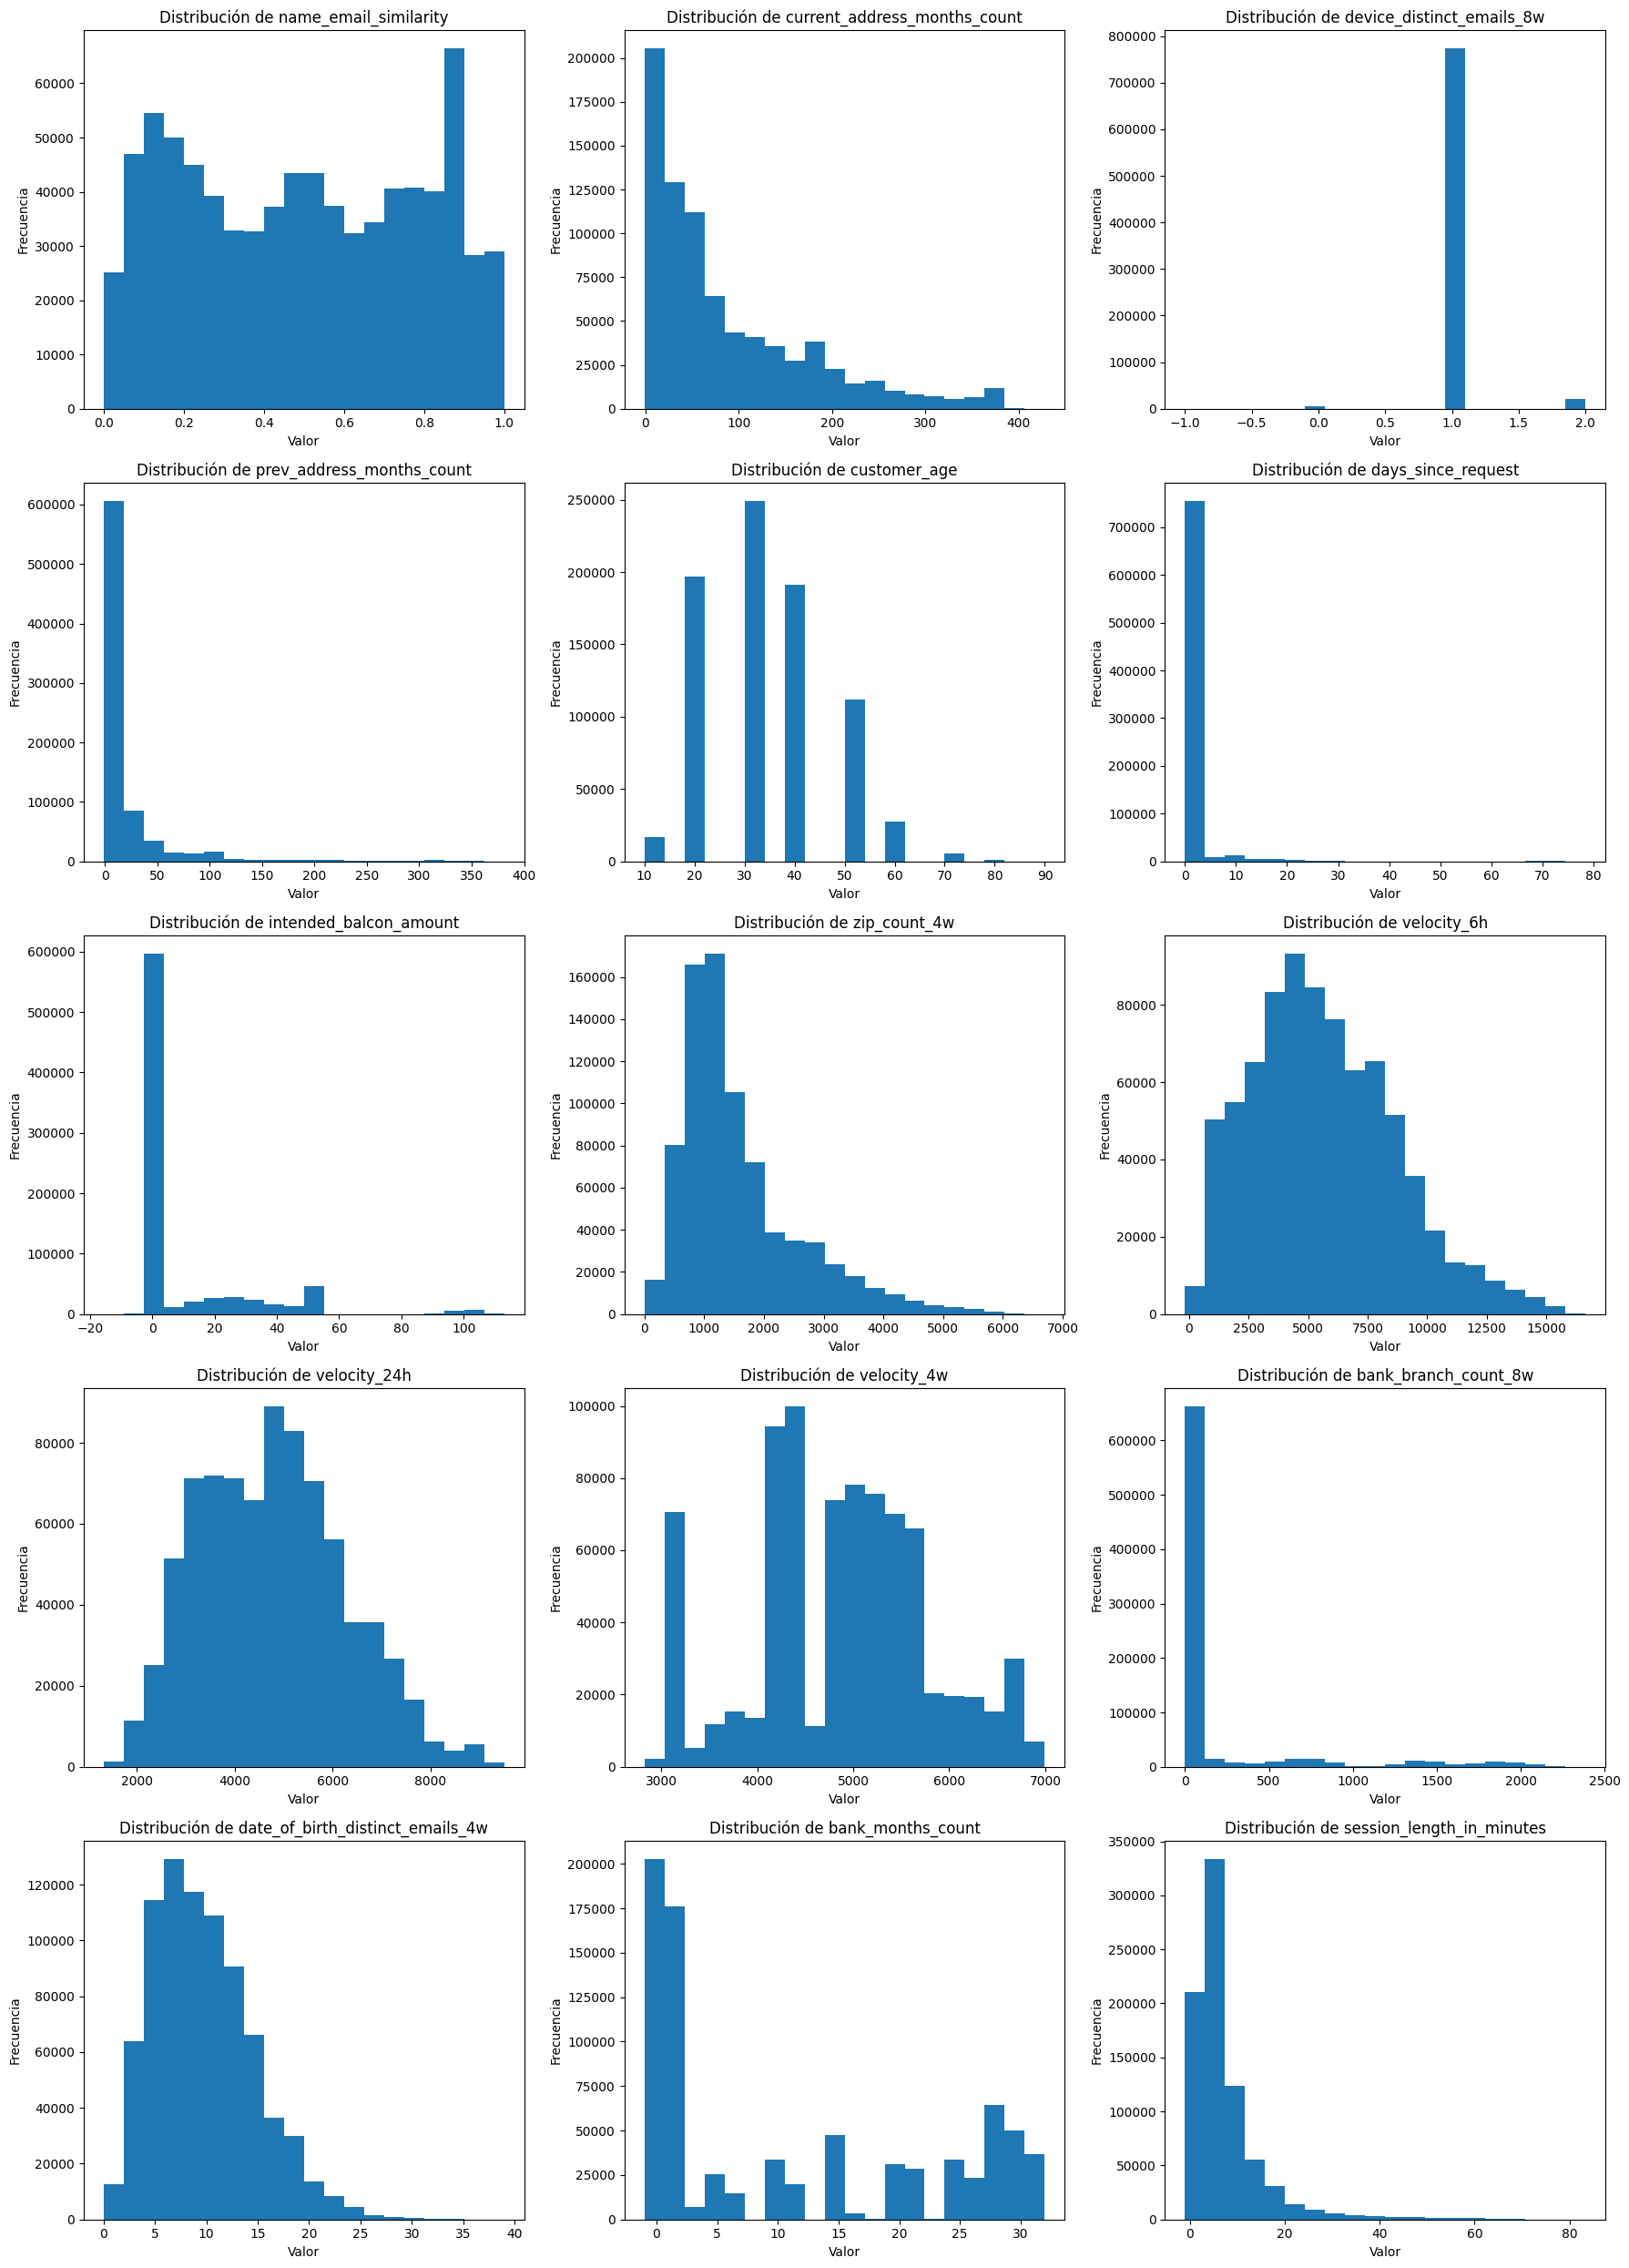

In [6]:
## Distribuciones de variables (continuas)

# Redefinimos las variables para excluir las ya tratadas como discretas
all_numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

truly_discrete_vars = [
    'phone_home_valid',
    'phone_mobile_valid',
    'foreign_request',
    'device_fraud_count',
    'email_is_free',
    'has_other_cards',
    'keep_alive_session',
    'month',
    'income',
    'proposed_credit_limit'
]

# Filtro para excluir las variables discretas de las numéricas
continuous_vars = [col for col in all_numeric_cols if col not in truly_discrete_vars]

# Filtro para que los distintos grupos de variables contengan sólo variables contínuas
original_positive_vars = [
    "name_email_similarity", "current_address_months_count", "phone_home_valid", "phone_mobile_valid"
]
original_negative_vars = [
    "foreign_request", "device_fraud_count", "device_distinct_emails_8w"
]

positive_vars = [v for v in original_positive_vars if v in continuous_vars]
negative_vars = [v for v in original_negative_vars if v in continuous_vars]
neutral_vars  = [col for col in continuous_vars if col not in set(positive_vars) | set(negative_vars)]


# Combinamos todos los subgrupos para mostrar los gráficos
all_continuous_vars = positive_vars + negative_vars + neutral_vars

print("=== VARIABLES CONTINUAS ===")

# Calculamos el número de filas
num_vars = len(all_continuous_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

# Hacemos una sola figura con todas las gráficas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(all_continuous_vars):
    ax = axes[i]
    ax.hist(X_train[var], bins=20)
    ax.set_title(f"Distribución de {var}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

# Escondemos las que no hemos usado
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Resumen breve del análisis de distribuciones

Se observan cuatro hallazgos clave:
1. **Sesgo positivo y colas largas** en variables como `zip_count_4w`, `bank_branch_count_8w`, `session_length_in_minutes` y direcciones en meses, con riesgo de outliers influyentes.
2. **Valores especiales y estructura zero-inflated** (`-1` en varias variables y pico fuerte en `days_since_request=0`).
3. **Patrones multimodales** (por ejemplo `name_email_similarity` y `velocity_4w`), que sugieren subgrupos de comportamiento.

### Tratamientos prioritarios

- Reetiquetar `-1` como faltante informado y crear flag de ausencia.
- Aplicar transformaciones robustas (`log1p`, clipping/winsorización) en variables muy sesgadas.
- Para variables con exceso de ceros: usar enfoque en dos etapas (indicador de cero + magnitud).

## Distribuciones (Variables discretas)

=== VARIABLES DISCRETAS ===


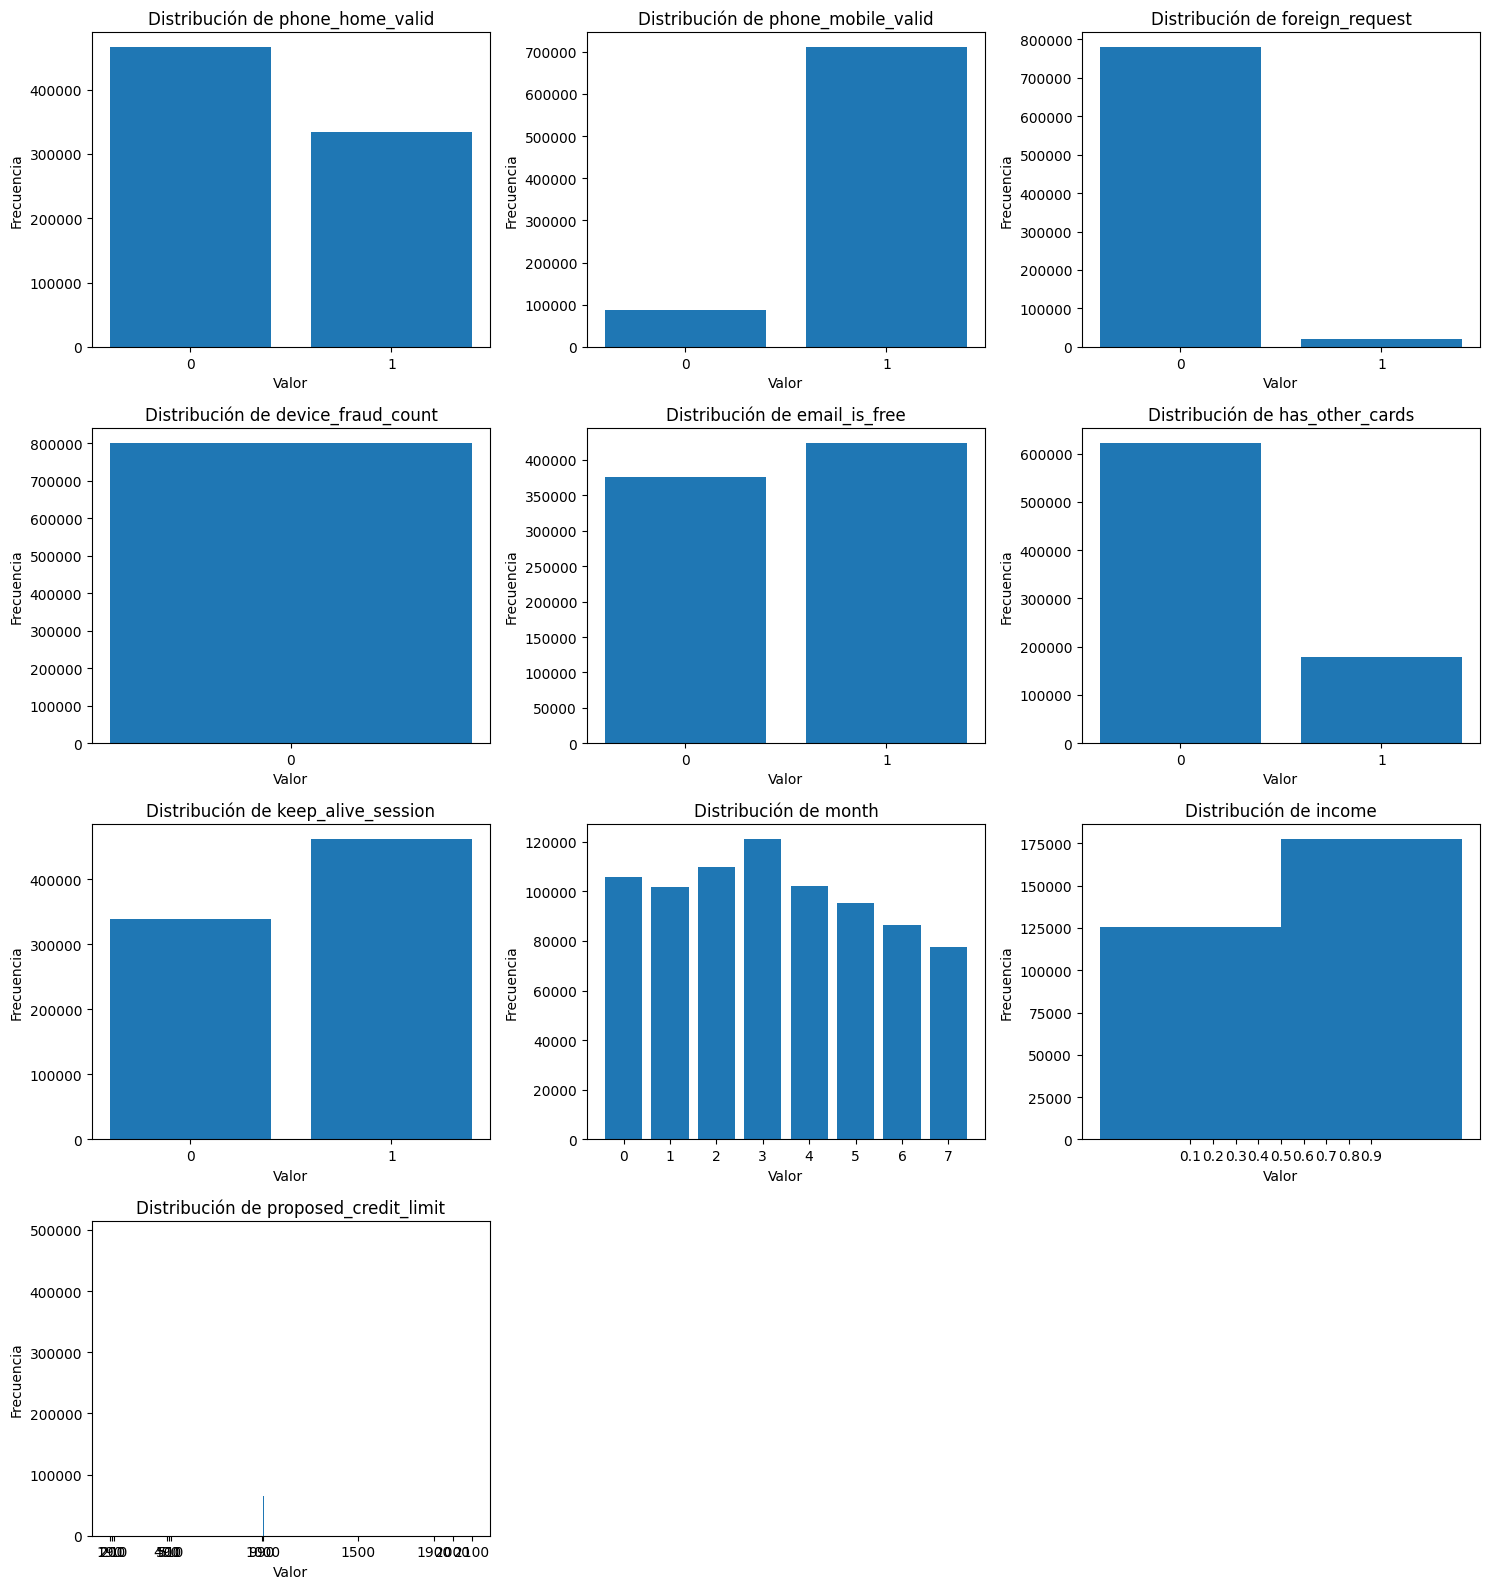

In [7]:
## Distribuciones de variables discretas

# Nos aseguramos que existen todas en el dataframe
truly_discrete_vars = [v for v in truly_discrete_vars if v in X_train.columns]

print("=== VARIABLES DISCRETAS ===")

# Fijamos el número de columnas y filas para mostrar los gráficos
num_vars = len(truly_discrete_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols

# Una sola figura para todos los gráficos, para no tener que recorrer todo el notebook para ver las gráficas y facilitar la comprensión
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(truly_discrete_vars):
    ax = axes[i]

    freq = X_train[var].value_counts().sort_index()

    ax.bar(freq.index, freq.values)
    ax.set_title(f"Distribución de {var}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.set_xticks(freq.index)  # Mostrar solo valores enteros presentes

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Problemas clave detectados:**
- **Fuerte desbalance** en varias binarias (`foreign_request`, `has_other_cards`, `phone_mobile_valid`).
- **Casi nula variabilidad** en `device_fraud_count` (prácticamente todo en 0).
- **No uniformidad temporal** en `month` (hay estacionalidad).
- **Variables discretizadas por niveles** (`income`, `proposed_credit_limit`), no continuas puras.

**Tratamiento recomendado:**
- Usar métricas y técnicas robustas al desbalance (class weights, muestreo, umbral).
- Eliminar o regularizar `device_fraud_count` si aporta señal mínima.
- Incluir `month` como efecto temporal (y validar por cortes temporales).
- Tratar `income` y `proposed_credit_limit` como ordinales/categóricas (binning/one-hot según modelo).

## Distribuciones (Variables categóricas)

También necesitaremos hacer un análisis de distribución de las columnas categóricas, por lo menos para ver cuántas de cada categoría existen:

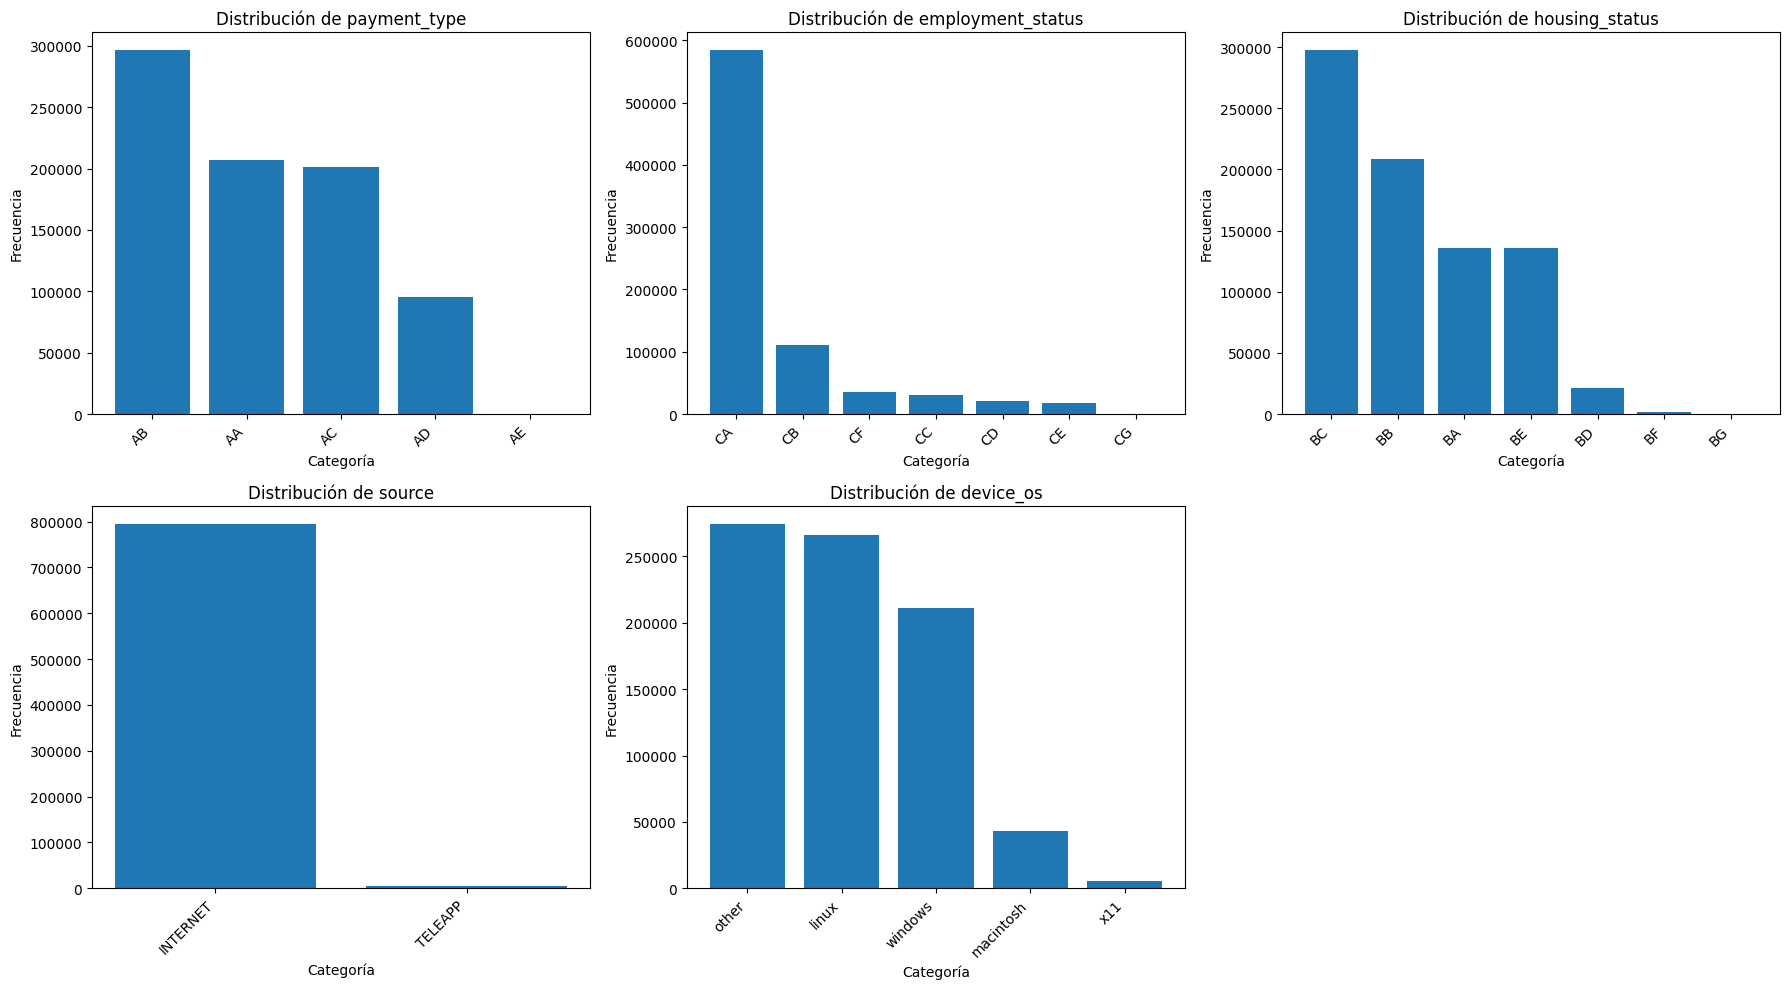

In [8]:
categorical_vars = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

# Este código es igual que los anteriores pero para las variables categóricas, si lo fuese a llamar más veces se habría creado como función, pero al ser sólo 3, se deja así
num_vars = len(categorical_vars)
n_cols = 3
n_rows = (num_vars + n_cols - 1) // n_cols


fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    ax = axes[i]
    freq = X_train[var].value_counts()
    ax.bar(freq.index, freq.values)
    ax.set_title(f"Distribución de {var}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")
    ax.set_xticks(freq.index)
    ax.set_xticklabels(freq.index, rotation=45, ha='right')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Problemas clave (categóricas):**
- **Desbalance severo** en `source` (casi todo `INTERNET`) y en `employment_status` (domina `CA`).
- **Categorías raras** con muy pocas muestras (`AE`, `CG`, `BG`, `BF`, `X11`), riesgo de ruido/sobreajuste.
- **Frecuencia desigual moderada** en `device_os`, `housing_status` y `payment_type`.

**Tratamiento recomendado (breve):**
- Agrupar categorías raras en `OTHER` (según umbral mínimo de frecuencia).
- Codificar con one-hot/target encoding con regularización (según modelo).
- Usar partición estratificada y validación robusta para evitar sesgo por clases dominantes.
- Revisar señal de `source` para evitar que su desbalance domine decisiones del modelo.

## Correlaciones

También necesitamos, para poder filtrar las variables de una forma más eficiente, conocer las relaciones entre estas, son datos sintéticos, pero las relaciones entre ellos pueden revelarnos qué variables son más valiosas, o pueden aportar solo ruido o causar sobre-entrenamiento.

Primero analizaremos las correlaciones entre las variables numéricas:

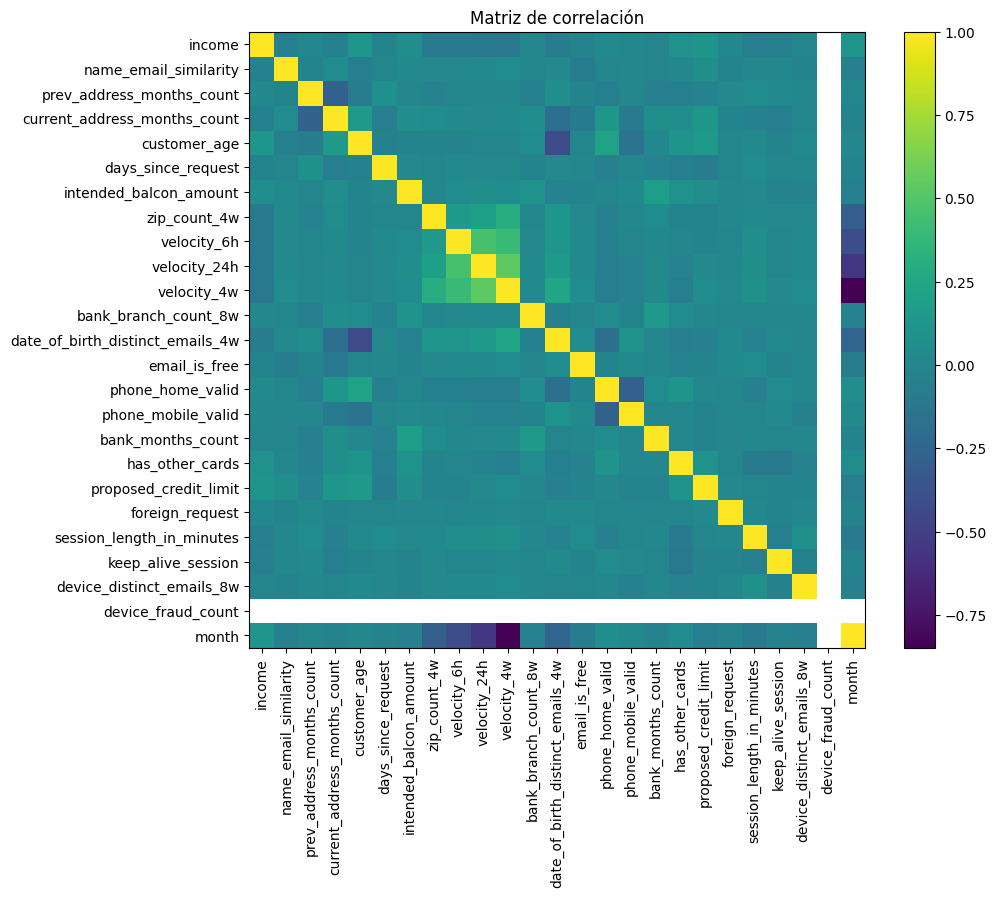

=== Correlaciones más altas (valor absoluto) ===


,Variable 1,Variable 2,Correlación
274,velocity_4w,month,-0.848485
249,velocity_24h,month,-0.549840
235,velocity_24h,velocity_4w,0.539298
209,velocity_6h,velocity_24h,0.463918
112,customer_age,date_of_birth_distinct_emails_4w,-0.419836
224,velocity_6h,month,-0.409619
210,velocity_6h,velocity_4w,0.400498
185,zip_count_4w,velocity_4w,0.303300
199,zip_count_4w,month,-0.287639
365,phone_home_valid,phone_mobile_valid,-0.272582


In [9]:
numeric_df = X_train.select_dtypes(include=[np.number])

# Calculamos matriz de correlación
corr_matrix = numeric_df.corr()

# Mostramos heatmap
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix)
plt.title("Matriz de correlación")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()


# ---------------------------------------------------
# EXTRAER CORRELACIONES MÁS ALTAS (EXCLUYENDO DIAGONAL)
# ---------------------------------------------------

# Convertimos matriz en formato largo
corr_long = corr_matrix.unstack().reset_index()
corr_long.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminamos autocorrelaciones
corr_long = corr_long[corr_long["Variable 1"] != corr_long["Variable 2"]]

# Eliminamos duplicados (A-B y B-A)
corr_long["ParOrdenado"] = corr_long.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])), axis=1
)
corr_long = corr_long.drop_duplicates(subset="ParOrdenado")
corr_long = corr_long.drop(columns="ParOrdenado")

# Ordenamos por valor absoluto de la correlación
corr_long["AbsCorr"] = corr_long["Correlación"].abs()
corr_long = corr_long.sort_values("AbsCorr", ascending=False)

# Mostramos las 10 correlaciones más altas
top_correlations = corr_long.head(10)

print("=== Correlaciones más altas (valor absoluto) ===")
display(top_correlations[["Variable 1", "Variable 2", "Correlación"]])

Observamos que existen correlaciones de valores tanto positivos como negativos, las más destables serían:

- (velocity_4w , month) con un -0.589 al ser negativa significa que a menor valor de mes, mayor valor de velocity_4w, tiene sentido ya que las transferencias a final de año son más bien por festividades y similares, y entre cuentas conocidas, que conllevan menos revisión, mientras que el resto del año suelen ser profesionales, con las que se suele tener más cuidado.
- (customer_age , date_of_birth_distinct_emails_4w) con un -0.448 que también es lógico, puesto que la piramide poblacional decrece con la edad.
- (velocity_6h , velocity_24h) con un 0.333 Tiene sentido, si han incrementado el número de transacciones en 6h, también aumentan en 24h
- (phone_home_valid , phone_mobile_valid) con un -0.300 también es lógico, puesto que actuálmente cada vez más gente sustituye el teléfono fijo por un smartphone.


## Análisis por variable categórica

Ahora pasaremos a buscar relaciones de las variables categóricas, primero con las numéricas, para ver si se observa alguna relación, después buscaremos relaciones entre las mismas variables categóricas.

En esta primera fase, buscamos analizar las variables categóricas y su relación con las variables contínuas.

In [10]:
var_groups = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

for var in var_groups:
    display(X_train.groupby(var).mean(numeric_only=True))



,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
payment_type,,,,,,,,,,,,,,,,,,,,,,,,,
AA,0.581315,0.506207,15.990586,95.949836,33.144258,1.423173,33.494673,1599.603857,6033.092185,4978.110397,4956.866644,292.364938,9.340679,0.513785,0.425998,0.918936,15.819905,0.317025,508.604370,0.025861,8.005697,0.560842,1.011496,0.0,3.084535
AB,0.555645,0.479840,14.167369,86.223343,34.766396,0.354917,0.059913,1550.663772,5452.919364,4638.773620,4770.234954,224.323899,9.293193,0.536292,0.456980,0.881622,13.949593,0.211864,537.466017,0.024728,7.077801,0.585586,1.019882,0.0,3.488429
AC,0.542884,0.498215,21.271483,79.380789,33.395254,1.861671,-0.691829,1527.864695,5521.103836,4669.727823,4784.250658,11.105304,9.381453,0.520905,0.361474,0.871419,-0.010662,0.183616,486.361955,0.021205,7.713498,0.564127,1.019831,0.0,3.424671
AD,0.587542,0.500103,16.648944,83.163171,32.090520,0.470039,1.390250,1678.412481,5823.211335,4928.377173,5057.288408,194.721236,10.763242,0.563520,0.389535,0.889240,13.393368,0.135559,530.965228,0.034330,7.667552,0.609086,1.025252,0.0,2.826446
AE,0.534483,0.455481,28.012931,99.370690,32.543103,1.437148,13.834204,1453.956897,6251.563343,5178.860994,5023.386432,196.228448,10.094828,0.530172,0.318966,0.823276,12.818966,0.211207,525.905172,0.038793,8.689220,0.461207,1.034483,0.0,2.659483


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
employment_status,,,,,,,,,,,,,,,,,,,,,,,,,
CA,0.569035,0.502381,17.722003,83.171754,32.580540,1.040190,8.876178,1547.974713,5552.696267,4704.474516,4812.541682,177.542123,9.707137,0.527844,0.387168,0.903530,10.730777,0.222049,539.706930,0.024926,7.447763,0.579425,1.017044,0.0,3.398360
CB,0.616693,0.461623,12.650745,97.689138,35.024675,0.963625,9.799055,1697.210957,6078.954059,5035.895423,5054.676567,205.772436,9.968687,0.535682,0.462073,0.894390,11.687653,0.222285,503.652827,0.032010,7.276821,0.600580,1.012894,0.0,2.791289
CC,0.524897,0.447291,14.153208,129.754438,51.650745,0.699842,5.666484,1542.815456,5833.042443,4893.445997,4915.557194,222.557168,4.037814,0.522361,0.712590,0.678842,11.411463,0.266519,506.102866,0.020890,9.606630,0.445080,1.056821,0.0,3.171289
CD,0.434556,0.479135,16.870291,75.921071,34.440568,1.583830,4.945462,1610.960724,5967.938415,4919.418925,4934.172654,173.504267,9.335565,0.535857,0.403555,0.847140,9.146400,0.189495,333.809232,0.021972,8.479571,0.518035,1.026215,0.0,3.060022
CE,0.420104,0.553772,13.562538,100.614941,26.948091,1.104105,12.592437,1569.489481,5893.454083,4856.073410,4828.886845,224.648229,9.263993,0.504587,0.386872,0.920297,12.519967,0.136885,363.221093,0.017578,7.870116,0.546993,1.015216,0.0,3.334139
CF,0.474622,0.467577,16.741560,71.934160,35.356787,0.853141,4.401655,1597.983988,5764.054868,4753.622564,4873.107964,189.039419,9.567106,0.561019,0.536646,0.833964,9.805665,0.264156,365.851654,0.019368,7.563276,0.618043,1.020989,0.0,3.255084
CG,0.561995,0.469559,19.587601,89.256065,35.417790,1.439492,11.131361,1448.005391,5826.268266,4843.321900,4795.926699,212.460916,9.005391,0.466307,0.487871,0.846361,12.129380,0.288410,566.630728,0.056604,8.085171,0.458221,1.005391,0.0,3.374663


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
housing_status,,,,,,,,,,,,,,,,,,,,,,,,,
BA,0.658531,0.488597,10.344968,133.202283,39.683716,0.605989,8.554292,1538.696781,5186.535108,4580.040190,4773.064923,186.748541,7.817473,0.461044,0.454611,0.841652,10.881517,0.259210,825.596758,0.028574,6.899616,0.505715,1.017783,0.0,3.512399
BB,0.529508,0.485727,15.356156,84.760225,36.253515,0.885230,4.352062,1561.358934,5628.892118,4700.055567,4820.294725,184.307911,8.973358,0.535944,0.481720,0.871062,10.055057,0.239104,445.439062,0.019518,7.702750,0.595969,1.024390,0.0,3.395019
BC,0.583584,0.481519,23.449218,46.742933,32.921250,1.321126,10.065091,1555.190776,5735.057414,4849.742289,4886.847548,176.883692,10.139334,0.574117,0.374942,0.908129,10.395356,0.226779,465.096442,0.028756,7.965574,0.588125,1.016499,0.0,3.181174
BD,0.588328,0.467571,22.289879,75.825643,34.356062,1.257754,9.259239,1454.245646,5326.710189,4506.741157,4656.644578,192.856754,9.025719,0.585914,0.443098,0.899890,10.826550,0.218018,536.978098,0.030062,7.789515,0.614067,1.018753,0.0,3.754688
BE,0.468699,0.541983,9.566090,132.125288,25.263710,0.964507,12.208075,1680.915908,6090.888285,4923.822763,4956.384594,198.061008,10.684856,0.483579,0.366328,0.924218,13.009980,0.152686,425.406793,0.022456,7.003212,0.586936,1.013636,0.0,3.071512
BF,0.558942,0.470967,21.307750,95.599851,34.284650,1.702728,12.772937,1548.991803,5958.985312,4989.905421,4953.102378,237.201937,9.211624,0.526080,0.473920,0.850969,12.648286,0.280179,459.411326,0.025335,7.651780,0.527571,1.011177,0.0,3.024590
BG,0.555500,0.529044,17.690000,102.190000,34.550000,1.320176,21.847786,1844.440000,5839.285971,5141.238936,5308.564860,291.210000,10.300000,0.450000,0.510000,0.885000,13.025000,0.305000,502.450000,0.025000,8.598560,0.535000,1.030000,0.0,2.415000


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
source,,,,,,,,,,,,,,,,,,,,,,,,,
INTERNET,0.563064,0.49386,16.761128,86.583353,33.658918,1.017035,8.68973,1572.881663,5665.550763,4767.796289,4856.003979,185.071991,9.512526,0.529853,0.416375,0.890164,10.874509,0.222174,516.712009,0.025385,7.575811,0.580073,1.021317,0.0,3.289443
TELEAPP,0.531056,0.46838,12.015537,96.138418,37.141596,2.082962,5.47109,1546.062323,5464.003600,4901.663632,4871.452170,122.342338,8.087218,0.526836,0.484640,0.806850,7.032662,0.316737,466.382415,0.010064,3.668149,0.081038,0.601518,0.0,3.259534


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
device_os,,,,,,,,,,,,,,,,,,,,,,,,,
linux,0.536116,0.473552,19.117223,78.085690,34.298211,1.112339,7.505123,1619.726788,5767.336397,4799.895244,4896.024962,178.014094,9.506349,0.626572,0.430020,0.901904,10.345541,0.230837,472.861138,0.034721,8.034996,0.593193,1.022706,0.0,3.168808
macintosh,0.597974,0.501718,19.066601,84.115970,31.325043,1.086029,10.959530,1543.174398,5626.006587,4771.322578,4775.803704,185.426412,9.417633,0.525779,0.330399,0.908714,11.276466,0.202482,539.864003,0.030041,7.564465,0.474407,1.018443,0.0,3.498463
other,0.572714,0.499774,15.142165,89.545930,31.857944,1.039126,10.477253,1542.446033,5648.708141,4763.031511,4831.307448,187.818020,9.879622,0.439568,0.391837,0.907962,10.669065,0.238445,492.524941,0.013269,6.863321,0.597778,1.006695,0.0,3.382141
windows,0.575728,0.509271,15.176049,94.228814,35.697904,0.865646,7.153803,1557.563327,5557.282089,4733.577101,4853.365701,187.075842,9.048097,0.524266,0.449728,0.846862,11.587328,0.197539,596.763998,0.027787,7.786739,0.549741,1.027825,0.0,3.278019
x11,0.592365,0.501838,21.241170,85.648026,35.997230,1.642469,14.459176,1614.804882,5829.694932,4871.040677,4893.274287,242.371884,8.643525,0.593663,0.440616,0.866863,12.190616,0.189924,538.346607,0.033241,8.803556,0.539647,1.023546,0.0,3.277874


El análisis de las medias de las variables numéricas agrupadas por cada variable categórica sugiere lo siguiente:

*   **Desbalance y homogeneidad**: Las variables categóricas con un fuerte desbalance, como `source` (dominada por `INTERNET`) y `employment_status` (dominada por `CA`), tienden a mostrar perfiles numéricos menos diferenciados entre sus categorías mayoritarias y la media global, ya que las categorías dominantes influyen en gran medida en la media general. Las categorías minoritarias pueden mostrar valores extremos, pero su relevancia estadística es limitada debido a su baja frecuencia.
*   **Potencial de diferenciación**: Otras variables como `device_os`, `housing_status` y `payment_type`, con distribuciones de categorías más moderadas, pueden revelar patrones más distintivos en las medias de las variables numéricas. Por ejemplo, ciertas categorías de `device_os` o `payment_type` podrían estar asociadas con montos de transacción (`intended_balcon_amount`) o velocidades (`velocity_6h`, `velocity_24h`, `velocity_4w`) promedio significativamente diferentes.

En general, aunque las correlaciones directas entre las variables categóricas son bajas, el análisis de sus perfiles con variables numéricas permite identificar tendencias. Sin embargo, la verdadera utilidad predictiva de estas variables probablemente reside en su combinación con otras características en modelos más complejos, donde sus interacciones pueden revelar patrones de fraude más robustos.

## Búsqueda de relaciones entre las variables categóricas


YA se ha buscado una relación entre las variables categóricas y las numéricas, pero para comprender bien los datos el análisis no estaría completo si no se realizarán varias tablas cruzadas con múltiples combinaciones de variables categóricas para analizar posibles patrones entre ellas, o incluso perfiles que previamente pasasen inadvertidos.

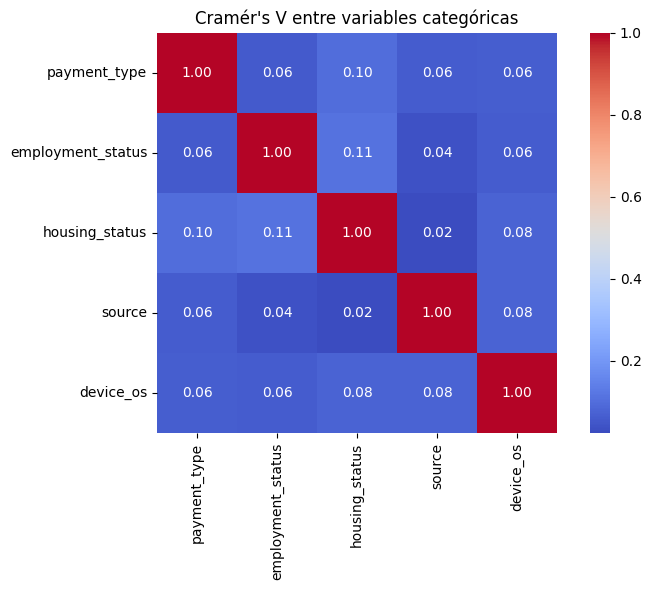

In [11]:
categorical_vars = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k))

labels = categorical_vars
matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

for col1, col2 in itertools.product(labels, repeat=2):
    matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Cramér's V entre variables categóricas")
plt.tight_layout()
plt.show()

El análisis de la matriz de Cramer's V y el mapa de calor revela que las **variables categóricas tienen una asociación muy débil entre sí**. Los valores de Cramer's V en la matriz, que miden la fuerza de la asociación entre dos variables nominales, son consistentemente bajos (la mayoría se encuentran entre 0.02 y 0.11).

Esto sugiere que el conocimiento de una variable categórica (por ejemplo, `payment_type`) no proporciona mucha información sobre los valores de otra variable categórica (como `employment_status` o `device_os`). En otras palabras, estas variables actúan de manera bastante independiente en el contexto del conjunto de datos.

### Implicaciones:
*   **Redundancia limitada:** Dado que las variables categóricas no están fuertemente correlacionadas entre sí, es poco probable que haya mucha redundancia en la información que proporcionan. Esto significa que cada variable podría aportar una perspectiva única al modelo.
*   **Análisis individual o combinado:** Aunque las correlaciones cruzadas son bajas, su interacción con la variable objetivo (`fraud_bool`) o con otras variables numéricas aún podría ser significativa. Sin embargo, su interdependencia directa es mínima.

## Ranking de probabilidad de transacción fraudulenta

Para calcular el ránking de probabilidad de que una transacción sea o no fraudulenta, nos basaremos en RIDIT Scoring Method ( https://www.researchgate.net/publication/395214664_Machine_Learning_Based_Fraud_Risk_Scoring_for_Financial_TransactionsUsing_a_Comparative_Study_of_Random_Forest_and_Support_VectorRegression_Models ) para ello, tras tratar las diversas variables, usaremos Random Forest para el cálculo de una probabilidad de base, tras lo cual se convertirían esas probabilidades en un "puntaje de rango".

## Resumen

Se ha realizado un análisis exploratorio completo del dataset de fraude bancario, incluyendo: carga y descripción de variables, limpieza inicial (eliminación de `credit_risk_score` para evitar fuga/sobreajuste), partición train/test, análisis de distribuciones (continuas, discretas y categóricas), correlaciones numéricas y búsqueda de perfiles por variables categóricas.

Principales hallazgos del análisis:
- Predominan distribuciones asimétricas y con colas largas en variables numéricas, con presencia de outliers potenciales.
- Existen valores especiales (por ejemplo `-1`) que representan ausencia/no aplicable y deben tratarse explícitamente.
- En variables discretas y categóricas hay desbalances importantes (algunas clases dominan y otras son muy raras).
- Se observan correlaciones relevantes entre variables de comportamiento transaccional (especialmente velocidades y relaciones con `month`).
- En perfiles categóricos simples, la señal más consistente aparece en `device_os`; el resto de variables categóricas muestran menor capacidad de diferenciación cuando se analizan de forma aislada.

## Conclusiones

1. El dataset es útil para detección de fraude, pero requiere un preprocesado cuidadoso para evitar sesgos y pérdida de robustez del modelo.
2. El tratamiento de desbalance de clases y categorías raras es crítico para obtener métricas realistas y modelos estables.
3. La ingeniería de características debe priorizar: manejo de valores especiales, transformación de variables sesgadas, codificación adecuada de categóricas y creación de interacciones entre variables.
4. Los perfiles de riesgo no parecen explicarse bien por una sola variable categórica; el valor principal está en combinaciones de señales.
5. Para la fase de modelado, se recomienda validar con métricas orientadas a fraude (Recall, Precision, F1 y PR-AUC), además de validación estratificada/temporal según el caso de uso.

## Tratando de predecir

En esta sección vamos a tratar predecir entrenando un modelo con un train set, si las transacciones del test set son fraudulentas o no. Midiendo el % de probabilidad de que sea fraudulenta, finalmente inferiremos más de un 50% de probabilidad como que tiene gran probabilidad de serlo, y por tanto que el modelo sugiere que es fraudulenta. Comparando teniendo en cuenta esto último lo que sugiere el modelo respecto a la realidad de esas transacciones del set de pruebas. Calculando el porcentaje de acierto global, y el % de acierto sobre las transacciones fraudulentas.

Hemos decidido emplear el modelo RandomForestClassifier ya que la cantidad de transacciones legítimas frente a fraudulentas está muy desbalanceado. También al usar este modelo no hemos tenido que descartar variables de las transacciones con baja correlacion o seleccionar solo las más correlacionadas con la variable fraud_bool, ya que el modelo lo hace directamente si no se le indica que variables usar.

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix, classification_report

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

modelo = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
modelo.fit(X_train_encoded, y_train)

y_pred = modelo.predict(X_test_encoded)
y_prob = modelo.predict_proba(X_test_encoded)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)
matriz = confusion_matrix(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"PR-AUC: {pr_auc:.4f}\n")
print("Matriz de confusión:")
print(matriz)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Precision: 0.0496
Recall: 0.7065
F1-Score: 0.0928
PR-AUC: 0.1140

Matriz de confusión:
[[169362  28529]
 [   619   1490]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    197891
           1       0.05      0.71      0.09      2109

    accuracy                           0.85    200000
   macro avg       0.52      0.78      0.51    200000
weighted avg       0.99      0.85      0.91    200000



In [13]:
resultados = pd.DataFrame({
    'Probabilidad_Fraude_(%)': y_prob * 100,
    'Prediccion_Modelo': y_pred,
    'Valor_Real': y_test.values
})

resultados['Acerto'] = resultados['Prediccion_Modelo'] == resultados['Valor_Real']

display(resultados.head(15))

fraudes_reales = resultados[resultados['Valor_Real'] == 1]
print("\n--- DETALLE DE CASOS REALMENTE FRAUDULENTOS ---")
display(fraudes_reales.head(15))

porcentaje_acierto_total = resultados['Acerto'].mean() * 100
acierto_en_fraudes = fraudes_reales['Acerto'].mean() * 100

print(f"\nPorcentaje de acierto global: {porcentaje_acierto_total:.2f}%")
print(f"Porcentaje de acierto en transacciones fraudulentas: {acierto_en_fraudes:.2f}%")

,Probabilidad_Fraude_(%),Prediccion_Modelo,Valor_Real,Acerto
0,16.657437,0,0,True
1,6.032373,0,0,True
2,9.263276,0,0,True
3,35.064932,0,0,True
4,41.334782,0,0,True
5,15.214586,0,0,True
6,28.037375,0,0,True
7,27.306826,0,0,True
8,20.897105,0,0,True
9,45.003514,0,0,True



--- DETALLE DE CASOS REALMENTE FRAUDULENTOS ---


,Probabilidad_Fraude_(%),Prediccion_Modelo,Valor_Real,Acerto
114,21.253005,0,1,False
353,31.356365,0,1,False
364,15.827944,0,1,False
368,79.365464,1,1,True
434,48.466712,0,1,False
477,79.803114,1,1,True
580,12.228756,0,1,False
801,17.232901,0,1,False
827,64.731956,1,1,True
859,39.177658,0,1,False



Porcentaje de acierto global: 85.43%
Porcentaje de acierto en transacciones fraudulentas: 70.65%


## Resultados

Podemos ver que el porcentaje de acierto global: 85.43% y el porcentaje de acierto en transacciones fraudulentas: 70.65%.

No son malos resultados para establecer el comienzo y durante el próximo hito trabajaremos en la optimización y mejora de precisión del modelo.